In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1)

pd.set_option("display.max_columns",None)

In [7]:
import pandas as pd

df = pd.read_csv("online_retail_II.csv")

In [8]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [10]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


In [11]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("online_retail_II.csv", encoding="ISO-8859-1")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [13]:
sample_df = df.sample(frac=0.10, random_state=42)

print(sample_df.shape)

(106737, 8)


In [14]:
sample_df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,414
Quantity,0
InvoiceDate,0
Price,0
Customer ID,24225
Country,0


In [15]:
sample_df = sample_df.dropna()

sample_df.shape

(82512, 8)

In [17]:
sample_df["InvoiceDate"] = pd.to_datetime(sample_df["InvoiceDate"])

sample_df["Customer ID"] = sample_df["Customer ID"].astype(int)

In [19]:
sample_df = sample_df[
    ~sample_df["Invoice"].astype(str).str.startswith("C")
]

In [20]:
sample_df = sample_df[
    (sample_df["Quantity"] > 0) &
    (sample_df["Price"] > 0)
]

In [21]:
sample_df["Revenue"] = sample_df["Quantity"] * sample_df["Price"]

sample_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
455941,532657,21314,SMALL GLASS HEART TRINKET POT,12,2010-11-14 11:10:00,2.10,14562,United Kingdom,25.20
826291,563214,22383,LUNCH BAG SUKI DESIGN,2,2011-08-14 12:56:00,1.65,16370,United Kingdom,3.30
191636,507597,22561,WOODEN SCHOOL COLOURING SET,12,2010-05-10 13:21:00,1.65,17700,United Kingdom,19.80
25864,491634,21588,RETRO SPOT GIANT TUBE MATCHES,1,2009-12-11 15:40:00,2.55,17841,United Kingdom,2.55
73233,496007,85232B,SET/3 RUSSIAN DOLL STACKING TINS,3,2010-01-28 12:32:00,4.95,15203,United Kingdom,14.85


In [22]:
country_revenue = (
    sample_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top10 = country_revenue.head(10)

print(top10)

Country
United Kingdom    1430331.111
EIRE                58845.530
Netherlands         55439.860
Germany             41031.800
France              34582.330
Australia           18417.380
Switzerland         10032.830
Spain               10019.960
Sweden               9817.090
Denmark              8048.400
Name: Revenue, dtype: float64


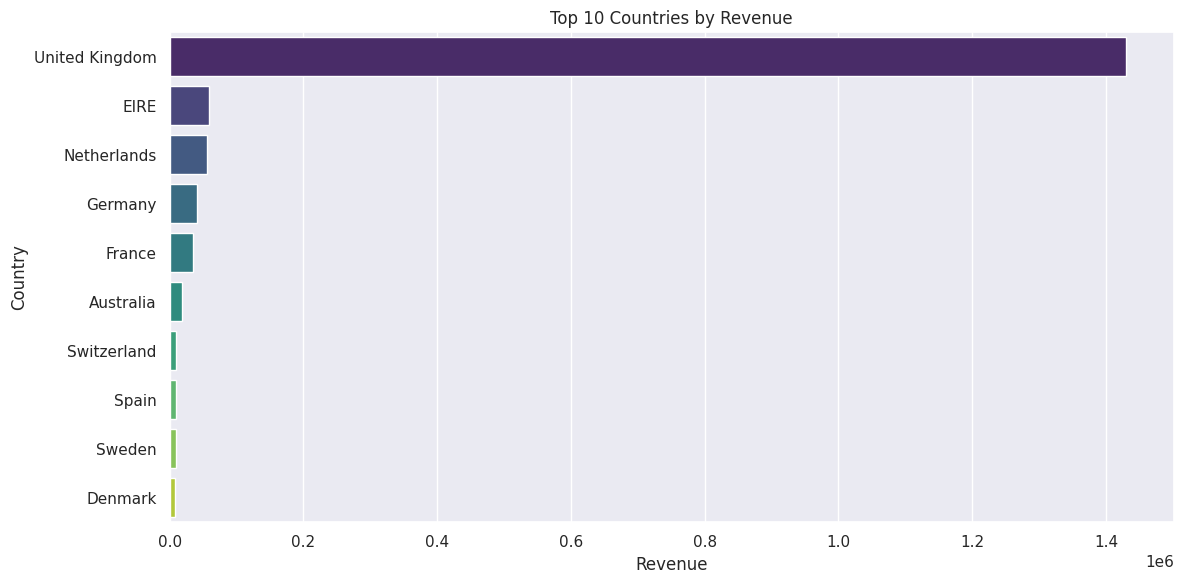

In [23]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

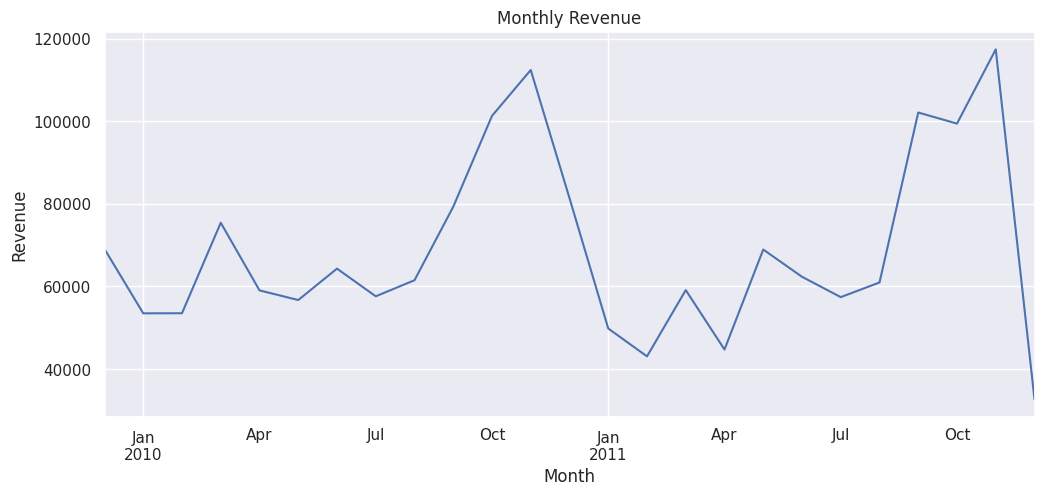

In [24]:
sample_df["Month"] = sample_df["InvoiceDate"].dt.to_period("M")

monthly = sample_df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(12,5))
monthly.plot()
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [25]:
top_products = (
    sample_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Description
REGENCY CAKESTAND 3 TIER              29543.85
WHITE HANGING HEART T-LIGHT HOLDER    23278.33
ASSORTED COLOUR BIRD ORNAMENT         15889.12
JUMBO BAG RED RETROSPOT               12407.13
POSTAGE                               11412.90
PARTY BUNTING                         10572.00
Manual                                 8894.01
PAPER CHAIN KIT 50'S CHRISTMAS         7971.02
HEART OF WICKER SMALL                  7773.75
BLACK RECORD COVER FRAME               7369.29
Name: Revenue, dtype: float64


In [26]:
top_customers = (
    sample_df.groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

Customer ID
14646    52843.98
18102    51064.21
14911    29342.50
14156    28279.96
17450    26651.38
17511    20751.51
13694    17459.24
17949    16807.52
12415    15909.08
16684    14981.46
Name: Revenue, dtype: float64


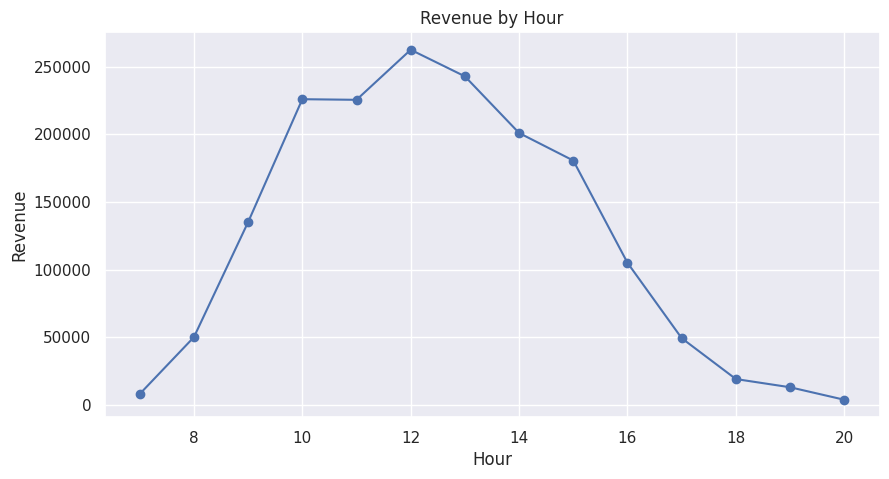

In [27]:
sample_df["Hour"] = sample_df["InvoiceDate"].dt.hour

hourly = sample_df.groupby("Hour")["Revenue"].sum()

plt.figure(figsize=(10,5))
hourly.plot(marker='o')
plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()